# PINN-MPC v6 Alpha: S&C Smooth Pitch Doublet Two-Case SimplePID vs MPPI Fast v22

This notebook tests the controllers with an explicit, simple reference trajectory instead of a learned or shaped guidance profile.

Default experiment with 60-second linear-guidance tracking:

- initial altitude: 3000 ft
- target altitude: 4000 ft
- guidance: linear altitude ramp over `GUIDANCE_CLIMB_TIME_S`
- controllers: PID and MPPI-MPC only

The goal is to isolate the controller behavior: if a clean linear reference is given, can PID and PINN-MPC follow it through the JSBSim C172 plant?

The guidance interface is written so later S&C maneuver references can be plugged in, such as pitch doublet, pull-up, pushover, and pull-up/pull-over.

Changes in v9:

- PID elevator sign is inverted for JSBSim C172 pitch-up convention
- linear climb time is relaxed from 125 s to 120 s
- progress cost is softened so MPPI is not dominated by unreachable short-horizon climb
- sanity check reports pitch-up direction, not only altitude change

Changes in v10:

- default run mode is `single`
- simulation time is 125 s (`MAX_STEPS = 3000`)
- expected altitude after 125 s is near 4000 ft for the 3000->4000 ft over 120 s reference
- adds reference tracking metrics against the pitch maneuver guidance, not only final target error

Changes in v22:

- renames quick check/summary helpers to tracking check/summary
- plots the linear altitude guidance reference with controller altitude traces
- saves tracking-specific CSV/figure names with v22


## 0. Install & Imports


In [1]:
!pip install jsbsim optuna -q
print('Install complete')


Install complete


In [2]:
import os, json, time, random, warnings, glob
warnings.filterwarnings('ignore')

import jsbsim
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import optuna

CKPT_FILENAME = 'pinn_dynamics_c172_2d_v6_alpha.pt'
COMPATIBLE_CKPT_FILENAMES = [
    'pinn_dynamics_c172_2d_v6_alpha.pt',
    'pinn_dynamics_c172_2d_v7_guidance_alpha.pt',
]
EXPERIMENT_FAMILY = 'PINN_MPC'
EXPERIMENT_NAME = 'v6_alpha_snc_smooth_pitch_doublet_two_case_simplePID_MPPI_fast_v22'
RUN_STAMP = time.strftime('%Y%m%d_%H%M%S')
COLAB_DRIVE_MOUNTED = False

try:
    from google.colab import drive
    drive.mount('/content/drive')
    COLAB_DRIVE_MOUNTED = True
except Exception:
    COLAB_DRIVE_MOUNTED = False

# Current training notebook saves v6 alpha here. Older project paths are kept as
# fallbacks so old Drive layouts still work. If needed, override MODEL_PATH after
# this cell before running the checkpoint load cell.
MODEL_PATH_CANDIDATES = []
for _name in COMPATIBLE_CKPT_FILENAMES:
    MODEL_PATH_CANDIDATES += [
        f'/content/drive/MyDrive/PINN_MODEL_ONLY_v1/{_name}',
        f'/content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/{_name}',
        f'/content/drive/MyDrive/PINN_MPC_Project/current best/PINN_Model/{_name}',
        f'/content/drive/MyDrive/PINN_MPC_Project/PINN_Model/{_name}',
        f'/content/drive/MyDrive/Colab Result/PINN_MPC/{_name}',
        f'/content/{_name}',
        f'./PINN_MODEL_ONLY_v1/{_name}',
        f'./PINN_MPC_Project/current best/PINN_Model/{_name}',
        f'./{_name}',
    ]

CHECKPOINT_SEARCH_ROOTS = [
    '/content/drive/MyDrive',
    '/content',
    '.',
]


def find_checkpoint_candidates():
    found = []
    for candidate in MODEL_PATH_CANDIDATES:
        if candidate and os.path.exists(candidate):
            found.append(candidate)

    patterns = []
    for root in CHECKPOINT_SEARCH_ROOTS:
        if os.path.exists(root):
            patterns.append(os.path.join(root, '**', 'pinn_dynamics_c172_2d*.pt'))
            patterns.append(os.path.join(root, '**', '*v6_alpha*.pt'))
            patterns.append(os.path.join(root, '**', '*v7_guidance_alpha*.pt'))

    for pattern in patterns:
        try:
            found.extend(glob.glob(pattern, recursive=True))
        except Exception as exc:
            print('Checkpoint search skipped pattern:', pattern, '|', repr(exc))

    # De-duplicate while preserving order, then prefer exact v6 alpha names.
    unique = []
    seen = set()
    for item in found:
        item = os.path.abspath(item)
        if item not in seen and os.path.exists(item):
            unique.append(item)
            seen.add(item)

    def rank(path):
        name = os.path.basename(path)
        if name == 'pinn_dynamics_c172_2d_v6_alpha.pt':
            return (0, -os.path.getmtime(path))
        if name == 'pinn_dynamics_c172_2d_v7_guidance_alpha.pt':
            return (1, -os.path.getmtime(path))
        return (2, -os.path.getmtime(path))

    return sorted(unique, key=rank)


def resolve_model_path():
    candidates = find_checkpoint_candidates()
    if candidates:
        return candidates[0]
    return MODEL_PATH_CANDIDATES[0]


MODEL_PATH = resolve_model_path()
FOUND_MODEL_PATHS = find_checkpoint_candidates()

# Result policy: code stays in the repository; generated outputs go to a
# separate Colab Result folder. Each run gets a timestamped archive directory.
RESULT_ROOT = '/content/drive/MyDrive/Colab Result' if COLAB_DRIVE_MOUNTED else './Colab Result'
RESULT_MODEL_DIR = os.path.join(RESULT_ROOT, EXPERIMENT_FAMILY, EXPERIMENT_NAME)
RESULT_ARCHIVE_DIR = os.path.join(RESULT_MODEL_DIR, 'archive')
RESULT_LATEST_DIR = os.path.join(RESULT_MODEL_DIR, 'latest')
SAVE_DIR = os.path.join(RESULT_ARCHIVE_DIR, RUN_STAMP)
for _path in [RESULT_ROOT, RESULT_MODEL_DIR, RESULT_ARCHIVE_DIR, RESULT_LATEST_DIR, SAVE_DIR]:
    os.makedirs(_path, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('COLAB_DRIVE_MOUNTED:', COLAB_DRIVE_MOUNTED)
print('MODEL_PATH:', MODEL_PATH)
print('MODEL_EXISTS:', os.path.exists(MODEL_PATH))
print('FOUND_MODEL_PATHS:')
for item in FOUND_MODEL_PATHS[:20]:
    print(' -', item)
if len(FOUND_MODEL_PATHS) > 20:
    print(f' ... {len(FOUND_MODEL_PATHS) - 20} more')
print('RESULT_ROOT:', RESULT_ROOT)
print('RESULT_MODEL_DIR:', RESULT_MODEL_DIR)
print('SAVE_DIR:', SAVE_DIR)
print('RESULT_LATEST_DIR:', RESULT_LATEST_DIR)
if not os.path.exists(MODEL_PATH):
    print('No compatible checkpoint was found. Put one of these files in Drive:')
    for name in COMPATIBLE_CKPT_FILENAMES:
        print(' - /content/drive/MyDrive/PINN_MODEL_ONLY_v1/' + name)
    print('Or set MODEL_PATH manually before running the checkpoint load cell.')

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu
COLAB_DRIVE_MOUNTED: True
MODEL_PATH: /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/pinn_dynamics_c172_2d_v6_alpha.pt
MODEL_EXISTS: True
FOUND_MODEL_PATHS:
 - /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/pinn_dynamics_c172_2d_v6_alpha.pt
 - /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/_Archive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v5_2_warmstart.pt
 - /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/_Archive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v5_1_sequence.pt
 - /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/_Archive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d.pt
RESULT_ROOT: /content/drive/MyDrive/Colab Result
RESULT_MODEL_DIR: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_two_case_disturbance_PID_MPPI_Optuna_v21


## 1. Configuration


In [2]:
# Run modes:
# - "quick": cost sanity check + fast PID vs MPPI comparison
# - "debug": MPPI-only short debug run
# - "single": PID vs MPPI with a little more time
# - "full": longer PID, Random Shooting, CEM, MPPI comparison
RUN_MODE = 'quick'
DEBUG_STRICT_ASSERTS = False
NOTEBOOK_REVISION = 'v22_snc_two_case_simplepid_mppi_fast'

# PINN is loaded only. No PINN data collection or training is performed here.
PINN_LOAD_ONLY = True

# Keep this False while debugging the MPC cost. PID tuning is slow and is not
# needed to check whether the MPC cost is shaped correctly.
TUNE_PID_WITH_OPTUNA = False
DEFAULT_PID_PARAMS = {
    'kp_alt': 0.0,
    'kp': 2.4,
    'ki': 0.006,
    'kd': 0.45,
    'kq': 0.9,
}

INIT_ALT = 3000.0
TARGET_ALT = INIT_ALT
THROTTLE = 0.85
DT = 0.02
FPS_PER_KT = 1.6878098571
INIT_SPEED_KTS = 100.0
INIT_SPEED_FPS = INIT_SPEED_KTS * FPS_PER_KT

STATE_COLS = ['h', 'V', 'theta', 'q', 'alpha']
INPUT_COLS = ['elevator', 'prev_elevator', 'delevator']
FEAT_COLS = STATE_COLS + INPUT_COLS
TGT_COLS = ['dh', 'dV', 'dtheta', 'dq', 'dalpha']

REACHED_BAND_FT = 100.0
REACHED_HOLD_STEPS = 60

PITCH_LIMIT_DEG = 25.0
PITCH_ABORT_DEG = 65.0
ALPHA_LIMIT_DEG = 18.0
ALT_MIN_FT = 500.0
ALT_MAX_FT = 12000.0

ELEV_LIMIT = 0.45
DELTA_ELEV_LIMIT = 0.08

# Recompute MPC only every N JSBSim steps. Quick mode uses 0.20 s updates.
CONTROL_INTERVAL = 10

# Explicit controller-test guidance. This is not PINN training guidance.
GUIDANCE_KIND = 'smooth_pitch_doublet'
SIM_TIME_S = 30.0
GUIDANCE_CLIMB_RATE_FPS = 0.0
GUIDANCE_CLIMB_TIME_S = SIM_TIME_S
GUIDANCE_LINEAR_START_ALT_FT = INIT_ALT
GUIDANCE_LINEAR_TARGET_ALT_FT = TARGET_ALT
GUIDANCE_TRIM_ALPHA_RAD = 0.035
GUIDANCE_AIRSPEED_KTS = 95.0
GUIDANCE_AIRSPEED_FPS = GUIDANCE_AIRSPEED_KTS * FPS_PER_KT
SPEED_FLOOR_KTS = 75.0
SPEED_FLOOR_FPS = SPEED_FLOOR_KTS * FPS_PER_KT
SPEED_TRACK_SCALE_FPS = 20.0
TERMINAL_SPEED_SCALE_FPS = 15.0
SUSTAINED_AUTHORITY_SECONDS = SIM_TIME_S
SUSTAINED_MIN_SPEED_KTS = SPEED_FLOOR_KTS
SUSTAINED_MIN_SPEED_FPS = SPEED_FLOOR_FPS
MANEUVER_KIND = GUIDANCE_KIND
MANEUVER_START_S = 5.0
MANEUVER_HALF_PERIOD_S = 3.0
MANEUVER_TOTAL_TIME_S = 2.0 * MANEUVER_HALF_PERIOD_S
MANEUVER_RECOVERY_S = 12.0
PITCH_DOUBLET_AMPLITUDE_DEG = 5.0
PITCH_PULSE_AMPLITUDE_DEG = 6.0
PITCH_PUSHOVER_AMPLITUDE_DEG = -4.0
DISTURBANCE_KIND = 'none'
DISTURBANCE_START_S = 12.0
DISTURBANCE_END_S = 26.0
DISTURBANCE_ELEVATOR_BIAS = 0.0
DISTURBANCE_ELEVATOR_SINE_AMP = 0.0
DISTURBANCE_ELEVATOR_FREQ_HZ = 0.35
DISTURBANCE_CASES = [
    {'name': 'W0_nominal', 'kind': 'none', 'bias': 0.0, 'sine_amp': 0.0, 'freq_hz': 0.35, 'start_s': 12.0, 'end_s': 26.0},
    {'name': 'W1_sine_step', 'kind': 'elevator_sine_step', 'bias': 0.018, 'sine_amp': 0.016, 'freq_hz': 0.35, 'start_s': 12.0, 'end_s': 26.0},
]
ACTIVE_DISTURBANCE_CASE = dict(DISTURBANCE_CASES[0])
CURRENT_GUIDANCE_TIME = 0.0
GUIDANCE_ALT_TRACK_SCALE_FT = 10.0
ALT_HOLD_SCALE_FT = 80.0
ALT_TERMINAL_SCALE_FT = 55.0
ALT_VS_SCALE_FPS = 12.0
GUIDANCE_VS_SCALE_FPS = 6.5
GUIDANCE_Q_SCALE_RAD_S = 0.10
THETA_CMD_LIMIT = 0.18
THETA_TRACK_SCALE = 0.055
GLOBAL_ALT_SCALE_FT = 600.0
GUIDANCE_PROGRESS_SCALE_FT = 8.0

# MPPI is still stochastic, so a few deterministic anchor sequences are added
# to avoid missing the climb direction with very small sample counts.
MPPI_USE_ANCHOR_SEQUENCES = True
MPPI_ANCHOR_LEVELS = [-0.30, -0.15, 0.0, 0.15, 0.30]

if RUN_MODE == 'quick':
    MAX_STEPS = 900
    PID_TRIALS = 0
    MPC_HORIZON = 100
    MPC_SAMPLES = 16
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'debug':
    MAX_STEPS = 500
    PID_TRIALS = 0
    MPC_HORIZON = 100
    MPC_SAMPLES = 16
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['MPPI']
elif RUN_MODE == 'single':
    MAX_STEPS = int(SIM_TIME_S / DT)
    PID_TRIALS = 0
    MPC_HORIZON = 120
    MPC_SAMPLES = 12
    CEM_ITERS = 1
    N_TEST_CASES = len(DISTURBANCE_CASES)
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'full':
    MAX_STEPS = int(SIM_TIME_S / DT)
    PID_TRIALS = 0
    MPC_HORIZON = 160
    MPC_SAMPLES = 20
    CEM_ITERS = 1
    N_TEST_CASES = 2
    SELECTED_CONTROLLERS = ['PID', 'Random', 'CEM', 'MPPI']
    TUNE_PID_WITH_OPTUNA = False
else:
    raise ValueError(f'Unknown RUN_MODE: {RUN_MODE}')

MPC_HORIZON_SECONDS = MPC_HORIZON * DT
CONTROL_INTERVAL_SECONDS = CONTROL_INTERVAL * DT
GUIDANCE_LINEAR_RATE_FPS = 0.0

CONFIG = dict(
    RUN_MODE=RUN_MODE,
    DEBUG_STRICT_ASSERTS=DEBUG_STRICT_ASSERTS,
    NOTEBOOK_REVISION=NOTEBOOK_REVISION,
    EXPERIMENT_FAMILY=EXPERIMENT_FAMILY,
    EXPERIMENT_NAME=EXPERIMENT_NAME,
    RUN_STAMP=RUN_STAMP,
    RESULT_ROOT=RESULT_ROOT,
    RESULT_MODEL_DIR=RESULT_MODEL_DIR,
    RESULT_ARCHIVE_DIR=RESULT_ARCHIVE_DIR,
    RESULT_LATEST_DIR=RESULT_LATEST_DIR,
    SAVE_DIR=SAVE_DIR,
    PINN_LOAD_ONLY=PINN_LOAD_ONLY,
    TUNE_PID_WITH_OPTUNA=TUNE_PID_WITH_OPTUNA,
    INIT_ALT=INIT_ALT,
    TARGET_ALT=TARGET_ALT,
    THROTTLE=THROTTLE,
    FPS_PER_KT=FPS_PER_KT,
    INIT_SPEED_KTS=INIT_SPEED_KTS,
    INIT_SPEED_FPS=INIT_SPEED_FPS,
    DT=DT,
    MAX_STEPS=MAX_STEPS,
    PID_TRIALS=PID_TRIALS,
    MPC_HORIZON=MPC_HORIZON,
    MPC_HORIZON_SECONDS=MPC_HORIZON_SECONDS,
    MPC_SAMPLES=MPC_SAMPLES,
    CEM_ITERS=CEM_ITERS,
    N_TEST_CASES=N_TEST_CASES,
    CONTROL_INTERVAL=CONTROL_INTERVAL,
    CONTROL_INTERVAL_SECONDS=CONTROL_INTERVAL_SECONDS,
    SELECTED_CONTROLLERS=SELECTED_CONTROLLERS,
    ELEV_LIMIT=ELEV_LIMIT,
    DELTA_ELEV_LIMIT=DELTA_ELEV_LIMIT,
    GUIDANCE_KIND=GUIDANCE_KIND,
    GUIDANCE_CLIMB_TIME_S=GUIDANCE_CLIMB_TIME_S,
    GUIDANCE_LINEAR_START_ALT_FT=GUIDANCE_LINEAR_START_ALT_FT,
    GUIDANCE_LINEAR_TARGET_ALT_FT=GUIDANCE_LINEAR_TARGET_ALT_FT,
    MANEUVER_KIND=MANEUVER_KIND,
    MANEUVER_TOTAL_TIME_S=MANEUVER_TOTAL_TIME_S,
    MANEUVER_START_S=MANEUVER_START_S,
    MANEUVER_HALF_PERIOD_S=MANEUVER_HALF_PERIOD_S,
    MANEUVER_RECOVERY_S=MANEUVER_RECOVERY_S,
    PITCH_DOUBLET_AMPLITUDE_DEG=PITCH_DOUBLET_AMPLITUDE_DEG,
    PITCH_PULSE_AMPLITUDE_DEG=PITCH_PULSE_AMPLITUDE_DEG,
    PITCH_PUSHOVER_AMPLITUDE_DEG=PITCH_PUSHOVER_AMPLITUDE_DEG,
    DISTURBANCE_CASES=DISTURBANCE_CASES,
    ACTIVE_DISTURBANCE_CASE=ACTIVE_DISTURBANCE_CASE,
    GUIDANCE_CLIMB_RATE_FPS=GUIDANCE_CLIMB_RATE_FPS,
    GUIDANCE_LINEAR_RATE_FPS=GUIDANCE_LINEAR_RATE_FPS,
    SIM_TIME_S=SIM_TIME_S,
    PID_ELEVATOR_SIGN=-1.0,
    EXPECTED_ALT_AT_SIM_END=GUIDANCE_LINEAR_TARGET_ALT_FT,
    SCENARIO_NOTE="Fast two-case smooth pitch-axis S&C maneuver: simple PID vs MPPI, no Optuna.",
    SPEED_UNIT_NOTE='JSBSim ic/vt-kts uses knots; PINN state V uses ft/s.',
    GUIDANCE_TRIM_ALPHA_RAD=GUIDANCE_TRIM_ALPHA_RAD,
    GUIDANCE_AIRSPEED_KTS=GUIDANCE_AIRSPEED_KTS,
    SPEED_FLOOR_KTS=SPEED_FLOOR_KTS,
    SPEED_FLOOR_FPS=SPEED_FLOOR_FPS,
    SPEED_TRACK_SCALE_FPS=SPEED_TRACK_SCALE_FPS,
    TERMINAL_SPEED_SCALE_FPS=TERMINAL_SPEED_SCALE_FPS,
    SUSTAINED_AUTHORITY_SECONDS=SUSTAINED_AUTHORITY_SECONDS,
    SUSTAINED_MIN_SPEED_KTS=SUSTAINED_MIN_SPEED_KTS,
    SUSTAINED_MIN_SPEED_FPS=SUSTAINED_MIN_SPEED_FPS,
    GUIDANCE_AIRSPEED_FPS=GUIDANCE_AIRSPEED_FPS,
    GUIDANCE_ALT_TRACK_SCALE_FT=GUIDANCE_ALT_TRACK_SCALE_FT,
    ALT_HOLD_SCALE_FT=ALT_HOLD_SCALE_FT,
    ALT_TERMINAL_SCALE_FT=ALT_TERMINAL_SCALE_FT,
    ALT_VS_SCALE_FPS=ALT_VS_SCALE_FPS,
    GUIDANCE_VS_SCALE_FPS=GUIDANCE_VS_SCALE_FPS,
    GUIDANCE_Q_SCALE_RAD_S=GUIDANCE_Q_SCALE_RAD_S,
    THETA_CMD_LIMIT=THETA_CMD_LIMIT,
    THETA_TRACK_SCALE=THETA_TRACK_SCALE,
    GLOBAL_ALT_SCALE_FT=GLOBAL_ALT_SCALE_FT,
    GUIDANCE_PROGRESS_SCALE_FT=GUIDANCE_PROGRESS_SCALE_FT,
    MPPI_USE_ANCHOR_SEQUENCES=MPPI_USE_ANCHOR_SEQUENCES,
    MPPI_ANCHOR_LEVELS=MPPI_ANCHOR_LEVELS,
)
print(json.dumps(CONFIG, indent=2))


NameError: name 'EXPERIMENT_FAMILY' is not defined

## 2. JSBSim Plant Helpers


In [4]:
def get_prop(fdm, name, default=0.0):
    try:
        return float(fdm[name])
    except Exception:
        return float(default)


def make_fdm(init_alt=INIT_ALT, init_speed=INIT_SPEED_KTS, init_pitch=0.0):
    fdm = jsbsim.FGFDMExec(None, None)
    fdm.set_debug_level(0)
    fdm.load_model('c172p')
    fdm['ic/h-sl-ft'] = float(init_alt)
    # JSBSim initial condition expects knots. read_state() returns ft/s.
    fdm['ic/vt-kts'] = float(init_speed)
    fdm['ic/theta-deg'] = float(init_pitch)
    fdm['ic/psi-true-deg'] = 0.0
    fdm.run_ic()
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/throttle-cmd-norm'] = THROTTLE
    return fdm


def read_state(fdm):
    return np.array([
        get_prop(fdm, 'position/h-sl-ft'),
        get_prop(fdm, 'velocities/vt-fps'),
        get_prop(fdm, 'attitude/theta-rad'),
        get_prop(fdm, 'velocities/q-rad_sec'),
        get_prop(fdm, 'aero/alpha-rad', 0.0),
    ], dtype=np.float32)


def set_disturbance_case(case):
    global ACTIVE_DISTURBANCE_CASE
    ACTIVE_DISTURBANCE_CASE = dict(case)


def elevator_disturbance(t):
    case = ACTIVE_DISTURBANCE_CASE
    kind = case.get('kind', 'none')
    if kind in (None, 'none'):
        return 0.0
    start_s = float(case.get('start_s', DISTURBANCE_START_S))
    end_s = float(case.get('end_s', DISTURBANCE_END_S))
    if t < start_s or t > end_s:
        return 0.0
    tau = t - start_s
    bias = float(case.get('bias', 0.0))
    sine_amp = float(case.get('sine_amp', 0.0))
    freq_hz = float(case.get('freq_hz', DISTURBANCE_ELEVATOR_FREQ_HZ))
    if kind == 'elevator_step':
        return bias
    if kind == 'elevator_sine':
        return sine_amp * np.sin(2.0 * np.pi * freq_hz * tau)
    if kind == 'elevator_sine_step':
        return bias + sine_amp * np.sin(2.0 * np.pi * freq_hz * tau)
    raise ValueError(f'Unknown disturbance kind: {kind}')


def apply_control(fdm, elevator, t=0.0, disturbance=0.0):
    total_elevator = float(np.clip(elevator + disturbance, -1.0, 1.0))
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/throttle-cmd-norm'] = THROTTLE
    fdm['fcs/elevator-cmd-norm'] = total_elevator
    fdm.run()
    return total_elevator


print('JSBSim helpers ready')


JSBSim helpers ready


## 3. Load Saved v6 Alpha PINN Checkpoint

This section reconstructs the network architecture and loads `model_state` from disk. It does not train, fit, optimize, or update the PINN parameters.


In [5]:
class PhysicsPINN(nn.Module):
    def __init__(self, hidden_dim=192, n_layers=4, stats=None):
        super().__init__()
        input_dim = len(FEAT_COLS)
        output_dim = len(TGT_COLS)
        self.register_buffer('Xm', stats['Xm'].clone() if stats else torch.zeros(input_dim))
        self.register_buffer('Xs', stats['Xs'].clone() if stats else torch.ones(input_dim))
        self.register_buffer('Ym', stats['Ym'].clone() if stats else torch.zeros(output_dim))
        self.register_buffer('Ys', stats['Ys'].clone() if stats else torch.ones(output_dim))

        layers = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x_norm):
        return self.net(x_norm)

    def denorm_delta(self, d_norm, add_mean=True):
        if add_mean:
            return d_norm * self.Ys + self.Ym
        return d_norm * self.Ys


def _torch_load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def load_pinn_checkpoint(path):
    candidates = []
    if path and os.path.exists(path):
        candidates.append(path)
    candidates.extend([p for p in FOUND_MODEL_PATHS if p not in candidates])

    load_errors = []
    for candidate in candidates:
        try:
            ckpt = _torch_load_checkpoint(candidate)
            missing = [k for k in ['model_state', 'stats', 'best_params'] if k not in ckpt]
            if missing:
                load_errors.append(f'{candidate}: missing keys {missing}')
                continue
            ckpt_features = list(ckpt.get('feature_cols', FEAT_COLS))
            ckpt_targets = list(ckpt.get('target_cols', TGT_COLS))
            if ckpt_features != FEAT_COLS or ckpt_targets != TGT_COLS:
                load_errors.append(
                    f'{candidate}: contract mismatch features={ckpt_features}, targets={ckpt_targets}'
                )
                continue
            return ckpt, candidate
        except Exception as exc:
            load_errors.append(f'{candidate}: {type(exc).__name__}: {exc}')

    message = [
        'Missing compatible trained PINN checkpoint.',
        f'Initial MODEL_PATH: {path}',
        'Expected feature contract:', str(FEAT_COLS),
        'Expected target contract:', str(TGT_COLS),
        'Searched/found candidates:',
    ]
    message += [f' - {p}' for p in (FOUND_MODEL_PATHS or MODEL_PATH_CANDIDATES[:10])]
    if load_errors:
        message += ['Load attempts:'] + [f' - {err}' for err in load_errors]
    message += [
        'Fix: run the v6 training notebook first, or copy a compatible checkpoint to:',
        '/content/drive/MyDrive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v6_alpha.pt',
        'You can also set MODEL_PATH manually before this cell.',
    ]
    raise FileNotFoundError('\n'.join(message))


assert PINN_LOAD_ONLY is True
checkpoint, MODEL_PATH = load_pinn_checkpoint(MODEL_PATH)

stats = {k: v.to(device) for k, v in checkpoint['stats'].items()}
params = checkpoint['best_params']

model = PhysicsPINN(
    hidden_dim=params.get('hidden_dim', 192),
    n_layers=params.get('n_layers', 4),
    stats=stats,
).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

ckpt_feature_cols = checkpoint.get('feature_cols', FEAT_COLS)
ckpt_target_cols = checkpoint.get('target_cols', TGT_COLS)

print('Loaded compatible PINN checkpoint:', MODEL_PATH)
print('PINN parameters frozen:', not any(p.requires_grad for p in model.parameters()))
print('best_params:', params)
print('feature_cols:', ckpt_feature_cols)
print('target_cols:', ckpt_target_cols)
print('auto_summary:', json.dumps(checkpoint.get('auto_summary', {}), indent=2))


Loaded compatible PINN checkpoint: /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/pinn_dynamics_c172_2d_v6_alpha.pt
PINN parameters frozen: True
best_params: {'hidden_dim': 192, 'n_layers': 4, 'lr': 0.0005, 'lam_physics': 0.1, 'lam_smooth': 0.0005, 'lam_rollout': 0.1, 'target_weights': [1.0, 1.0, 2.0, 8.0, 2.0], 'epochs': 340}
feature_cols: ['h', 'V', 'theta', 'q', 'alpha', 'elevator', 'prev_elevator', 'delevator']
target_cols: ['dh', 'dV', 'dtheta', 'dq', 'dalpha']
auto_summary: {
  "best_cycle": 0,
  "best_rollout_score_val": 0.3200063483543797,
  "best_h_rmse_mean_val": 0.37132277619093657,
  "best_theta_rmse_mean_val": 0.0007993993785930797,
  "best_q_rmse_mean_val": 0.0018216835087514482,
  "final_rollout_score_test": 0.1880706141043144,
  "final_h_rmse_mean_test": 0.21852892497554421,
  "final_theta_rmse_mean_test": 0.0006437486226786859,
  "final_q_rmse_mean_test": 0.0007485623646061867,
  "test_targets_met": true,
  "auto_cycles_run": 0,
  "auto

## 4. PINN Rollout for Control


In [6]:
@torch.no_grad()
def pinn_step(model, state, elevator, prev_elevator):
    elevator = float(np.clip(elevator, -ELEV_LIMIT, ELEV_LIMIT))
    prev_elevator = float(np.clip(prev_elevator, -ELEV_LIMIT, ELEV_LIMIT))
    delevator = elevator - prev_elevator
    x = np.array([state[0], state[1], state[2], state[3], state[4],
                  elevator, prev_elevator, delevator], dtype=np.float32)
    xt = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
    xn = (xt - model.Xm) / model.Xs
    dn = model(xn)
    delta = model.denorm_delta(dn, add_mean=True).cpu().numpy()[0]
    return state + delta


@torch.no_grad()
def rollout_pinn_control(model, init_state, elevator_seq, prev_elevator):
    states = [np.asarray(init_state, dtype=np.float32).copy()]
    current = states[0].copy()
    prev = float(prev_elevator)
    applied = []
    for raw_elev in elevator_seq:
        elev = float(np.clip(raw_elev, prev - DELTA_ELEV_LIMIT, prev + DELTA_ELEV_LIMIT))
        elev = float(np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT))
        current = pinn_step(model, current, elev, prev)
        states.append(current.copy())
        applied.append(elev)
        prev = elev
    return np.asarray(states), np.asarray(applied, dtype=np.float32)


print('PINN control rollout ready')


PINN control rollout ready


## 5. PID Baseline Tuning


In [7]:
class TunedPID:
    def __init__(self, params):
        self.kp_alt = params.get('kp_alt', 0.0)
        self.kp = params['kp']
        self.ki = params['ki']
        self.kd = params['kd']
        self.kq = params.get('kq', 0.0)
        self.integral = 0.0
        self.prev_err = 0.0
        self.prev_elev = 0.0
        self.ILIM = 8.0

    def reset(self):
        self.integral = 0.0
        self.prev_err = 0.0
        self.prev_elev = 0.0

    def update(self, state, target_alt):
        h, V, theta, q, alpha = state
        theta_cmd = guidance_first_theta(state, target_alt)
        err = theta_cmd - theta
        self.integral = np.clip(self.integral + err * DT, -self.ILIM, self.ILIM)
        deriv = (err - self.prev_err) / DT
        self.prev_err = err

        raw_cmd = self.kp * err + self.ki * self.integral + self.kd * deriv - self.kq * q
        raw = -raw_cmd
        elev = np.clip(raw, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT)
        elev = np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT)
        self.prev_elev = float(elev)
        return float(elev), {'theta_cmd': float(theta_cmd), 'cost': abs(theta_cmd - theta)}


def eval_pid_params(params, case=None, init_alt=INIT_ALT, target_alt=TARGET_ALT, n_steps=None):
    case = DISTURBANCE_CASES[0] if case is None else case
    set_disturbance_case(case)
    controller = TunedPID(params)
    fdm = make_fdm(init_alt=init_alt, init_speed=INIT_SPEED_KTS)
    n_steps = int(SIM_TIME_S / DT) if n_steps is None else int(n_steps)
    pitch, theta_ref, q_vals, alpha_vals, elevs, alt, speed = [], [], [], [], [], [], []

    global CURRENT_GUIDANCE_TIME
    for step in range(n_steps):
        t_now = step * DT
        CURRENT_GUIDANCE_TIME = t_now
        state = read_state(fdm)
        h, V, theta, q, alpha = state
        if h < ALT_MIN_FT or h > ALT_MAX_FT or abs(np.degrees(theta)) > PITCH_ABORT_DEG:
            return 1e8
        elev, info = controller.update(state, target_alt)
        disturb = elevator_disturbance(t_now)
        applied = apply_control(fdm, elev, t=t_now, disturbance=disturb)
        pitch.append(np.degrees(theta))
        theta_ref.append(np.degrees(info['theta_cmd']))
        q_vals.append(np.degrees(q))
        alpha_vals.append(np.degrees(alpha))
        elevs.append(applied)
        alt.append(h)
        speed.append(V)

    pitch = np.asarray(pitch)
    theta_ref = np.asarray(theta_ref)
    q_vals = np.asarray(q_vals)
    alpha_vals = np.asarray(alpha_vals)
    elevs = np.asarray(elevs)
    alt = np.asarray(alt)
    speed = np.asarray(speed)
    err = pitch - theta_ref

    pitch_rmse = np.sqrt(np.nanmean(err ** 2))
    peak_err = np.nanmax(np.abs(err))
    final_err = abs(err[-1])
    pitch_pen = 2.0 * np.mean(np.maximum(0.0, np.abs(pitch) - PITCH_LIMIT_DEG) ** 2)
    alpha_pen = 2.0 * np.mean(np.maximum(0.0, np.abs(alpha_vals) - ALPHA_LIMIT_DEG) ** 2)
    q_pen = 0.015 * np.mean(q_vals ** 2)
    effort = 2.0 * np.mean(np.diff(elevs, prepend=elevs[0]) ** 2)
    alt_pen = 0.002 * np.sqrt(np.mean((alt - target_alt) ** 2))
    speed_pen = 0.05 * np.mean(np.maximum(0.0, SPEED_FLOOR_FPS - speed) / SPEED_TRACK_SCALE_FPS)
    return float(1.00 * pitch_rmse + 0.18 * peak_err + 0.10 * final_err + pitch_pen + alpha_pen + q_pen + effort + alt_pen + speed_pen)


def pid_objective(trial):
    params = {
        'kp_alt': 0.0,
        'kp': trial.suggest_float('kp', 0.15, 5.0, log=True),
        'ki': trial.suggest_float('ki', 0.0001, 0.08, log=True),
        'kd': trial.suggest_float('kd', 0.01, 2.5, log=True),
        'kq': trial.suggest_float('kq', 0.0, 2.5),
    }
    return 0.65 * eval_pid_params(params, DISTURBANCE_CASES[0]) + 0.35 * eval_pid_params(params, DISTURBANCE_CASES[1])


def tune_pid_if_requested():
    global PID_PARAMS
    if TUNE_PID_WITH_OPTUNA and PID_TRIALS > 0:
        print(f'Tuning PID gains with {PID_TRIALS} Optuna trials for pitch maneuver tracking.')
        pid_study = optuna.create_study(direction='minimize')
        pid_study.optimize(pid_objective, n_trials=PID_TRIALS, show_progress_bar=True)
        PID_PARAMS = dict(pid_study.best_params)
        PID_PARAMS['kp_alt'] = 0.0
        print('Best PID params:', PID_PARAMS)
        print('Best PID objective:', pid_study.best_value)
        return pid_study
    PID_PARAMS = dict(DEFAULT_PID_PARAMS)
    print('Using simple DEFAULT_PID_PARAMS without Optuna:', PID_PARAMS)
    return None


PID_PARAMS = dict(DEFAULT_PID_PARAMS)
print('PID class and Optuna tuner ready')


PID class and Optuna tuner ready


## 6. MPC Cost Function


In [8]:
def _as_state_vector(current_state):
    arr = np.asarray(current_state, dtype=np.float32)
    if arr.ndim == 0 or arr.size == 1:
        return np.array([INIT_ALT, GUIDANCE_AIRSPEED_FPS, 0.0, 0.0, GUIDANCE_TRIM_ALPHA_RAD], dtype=np.float32)
    if arr.size < 5:
        raise ValueError('Guidance requires state [h, V, theta, q, alpha] or a scalar fallback.')
    return arr[:5].astype(np.float32)


def pitch_maneuver_theta_profile(t_abs):
    t_abs = np.asarray(t_abs, dtype=np.float32)
    theta_deg = np.zeros_like(t_abs, dtype=np.float32)
    a = float(PITCH_DOUBLET_AMPLITUDE_DEG)
    t0 = float(MANEUVER_START_S)
    half = float(MANEUVER_HALF_PERIOD_S)
    tau = t_abs - t0

    if MANEUVER_KIND in ('smooth_pitch_doublet', 'pitch_doublet'):
        first = (tau >= 0.0) & (tau < half)
        second = (tau >= half) & (tau < 2.0 * half)
        # Smooth S&C-style doublet: each lobe starts and ends at zero with a
        # half-sine shape, avoiding an impossible pitch step command.
        theta_deg[first] = a * np.sin(np.pi * tau[first] / half)
        theta_deg[second] = -a * np.sin(np.pi * (tau[second] - half) / half)
    elif MANEUVER_KIND == 'pullup_pushover':
        first = (tau >= 0.0) & (tau < half)
        second = (tau >= half) & (tau < 2.0 * half)
        theta_deg[first] = float(PITCH_PULSE_AMPLITUDE_DEG) * np.sin(np.pi * tau[first] / half)
        theta_deg[second] = float(PITCH_PUSHOVER_AMPLITUDE_DEG) * np.sin(np.pi * (tau[second] - half) / half)
    else:
        raise ValueError(f'Unknown MANEUVER_KIND: {MANEUVER_KIND}')
    return np.deg2rad(theta_deg).astype(np.float32)




def maneuver_reference_arrays(t, target_alt=TARGET_ALT):
    t = np.asarray(t, dtype=float)
    theta_ref_deg = np.degrees(pitch_maneuver_theta_profile(t))
    h_ref = np.ones_like(t) * float(target_alt)
    return h_ref, theta_ref_deg

def make_pitch_maneuver_guidance(current_state, target_alt, horizon, dt):
    state = _as_state_vector(current_state)
    h0, V0, theta0, q0, alpha0 = [float(v) for v in state]
    horizon = int(horizon)
    if horizon <= 0:
        raise ValueError('horizon must be positive')

    t_rel = np.arange(horizon, dtype=np.float32) * float(dt)
    t_abs = float(CURRENT_GUIDANCE_TIME) + t_rel
    theta_ref = pitch_maneuver_theta_profile(t_abs)
    q_ref = np.gradient(theta_ref, dt).astype(np.float32)
    h_ref = np.ones(horizon, dtype=np.float32) * float(target_alt)
    vz_ref = np.zeros(horizon, dtype=np.float32)
    speed_ref = np.ones(horizon, dtype=np.float32) * GUIDANCE_AIRSPEED_FPS
    alpha_ref = np.ones(horizon, dtype=np.float32) * np.clip(
        GUIDANCE_TRIM_ALPHA_RAD if abs(alpha0) < 0.20 else alpha0,
        -0.12, 0.16,
    )
    return {
        'h_ref': h_ref,
        'vz_ref': vz_ref,
        'V_ref': speed_ref.astype(np.float32),
        'theta_ref': theta_ref,
        'q_ref': q_ref,
        'alpha_ref': alpha_ref,
        'target_alt': float(target_alt),
        'desired_vs': 0.0,
        'initial_error': float(target_alt - h0),
        'profile': MANEUVER_KIND,
        't_abs': t_abs.astype(np.float32),
    }


def make_linear_altitude_guidance(current_state, target_alt, horizon, dt):
    return make_pitch_maneuver_guidance(current_state, target_alt, horizon, dt)


def make_maneuver_guidance(current_state, target_alt, horizon, dt, maneuver='pitch_doublet'):
    return make_pitch_maneuver_guidance(current_state, target_alt, horizon, dt)


def make_mpc_altitude_guidance(current_state, target_alt, horizon, dt):
    return make_maneuver_guidance(current_state, target_alt, horizon, dt, maneuver=GUIDANCE_KIND)


def make_altitude_guidance(current_state, target_alt, horizon, dt):
    guide = make_mpc_altitude_guidance(current_state, target_alt, horizon, dt)
    return guide['h_ref'], guide['vz_ref'], guide['theta_ref']


def guidance_first_theta(current_state, target_alt):
    guide = make_mpc_altitude_guidance(current_state, target_alt, 2, DT)
    return float(guide['theta_ref'][0])


def mpc_cost_components(predicted, target_alt, elev_seq):
    h = predicted[:, 0]
    V = predicted[:, 1]
    theta = predicted[:, 2]
    q = predicted[:, 3]
    alpha = predicted[:, 4]
    elev_seq = np.asarray(elev_seq, dtype=np.float32)

    guide = make_mpc_altitude_guidance(predicted[0], target_alt, len(h), DT)
    h_ref = guide['h_ref']
    theta_ref = guide['theta_ref']
    q_ref = guide['q_ref']
    alpha_ref = guide['alpha_ref']
    V_ref = guide['V_ref']

    dhdt = np.diff(h, prepend=h[0]) / DT
    theta_deg = np.degrees(theta)
    q_deg = np.degrees(q)
    alpha_deg = np.degrees(alpha)

    components = {
        'theta_track': 7.00 * np.mean(((theta - theta_ref) / THETA_TRACK_SCALE) ** 2),
        'theta_terminal': 3.00 * ((theta[-1] - theta_ref[-1]) / THETA_TRACK_SCALE) ** 2,
        'q_track': 0.15 * np.mean(((q - q_ref) / GUIDANCE_Q_SCALE_RAD_S) ** 2),
        'alpha_track': 0.04 * np.mean(((alpha - alpha_ref) / max(np.deg2rad(8.0), 1e-6)) ** 2),
        'alt_hold': 0.85 * np.mean(((h - h_ref) / ALT_HOLD_SCALE_FT) ** 2),
        'alt_terminal': 1.25 * ((h[-1] - h_ref[-1]) / ALT_TERMINAL_SCALE_FT) ** 2,
        'vz_hold': 0.35 * np.mean((dhdt / ALT_VS_SCALE_FPS) ** 2),
        'speed_track': 0.45 * np.mean(((V - V_ref) / SPEED_TRACK_SCALE_FPS) ** 2),
        'speed_floor': 1.50 * np.mean((np.maximum(0.0, SPEED_FLOOR_FPS - V) / SPEED_TRACK_SCALE_FPS) ** 2),
        'pitch_limit': 25.0 * np.mean(np.maximum(0.0, np.abs(theta_deg) - PITCH_LIMIT_DEG) ** 2),
        'alpha_limit': 25.0 * np.mean(np.maximum(0.0, np.abs(alpha_deg) - ALPHA_LIMIT_DEG) ** 2),
        'q_penalty': 0.004 * np.mean(q_deg ** 2),
        'effort': 0.003 * np.mean(elev_seq ** 2) if len(elev_seq) else 0.0,
        'smooth': 0.020 * np.mean(np.diff(elev_seq, prepend=elev_seq[0]) ** 2) if len(elev_seq) else 0.0,
    }

    unsafe = np.any((h < ALT_MIN_FT) | (h > ALT_MAX_FT) | (np.abs(theta_deg) > PITCH_ABORT_DEG))
    components['abort'] = 1e3 if unsafe else 0.0
    components = {k: float(v) for k, v in components.items()}
    components['total'] = float(sum(components.values()))
    return components, guide


def mpc_cost(predicted, target_alt, elev_seq):
    components, _ = mpc_cost_components(predicted, target_alt, elev_seq)
    return components['total']


## 7. PINN-MPC Controllers


In [9]:
class RandomShootingMPC:
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.20):
        self.horizon = horizon
        self.n_samples = n_samples
        self.sigma = sigma
        self.U = np.zeros(horizon, dtype=np.float32)
        self.prev_elev = 0.0

    def reset(self):
        self.U[:] = 0.0
        self.prev_elev = 0.0

    def sample_sequences(self):
        noise = np.random.normal(0.0, self.sigma, size=(self.n_samples, self.horizon))
        return np.clip(self.U[None, :] + noise, -ELEV_LIMIT, ELEV_LIMIT)

    def update(self, state, target_alt):
        seqs = self.sample_sequences()
        costs = np.empty(self.n_samples)
        applied_cache = []
        for i, seq in enumerate(seqs):
            pred, applied = rollout_pinn_control(model, state, seq, self.prev_elev)
            costs[i] = mpc_cost(pred, target_alt, applied)
            applied_cache.append(applied)

        best_idx = int(np.argmin(costs))
        best_applied = applied_cache[best_idx]
        action = float(best_applied[0])
        self.prev_elev = action
        self.U = np.append(best_applied[1:], best_applied[-1]).astype(np.float32)
        return action, {'cost': float(costs[best_idx]), 'best_cost': float(costs[best_idx])}


class CEMMPC:
    """
    Cross-Entropy Method MPC.

    CEM samples candidate control sequences around a nominal mean sequence,
    keeps only the elite low-cost samples, then updates the mean and standard
    deviation from those elites.
    """
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES,
                 elite_frac=0.15, init_sigma=0.22, min_sigma=0.04,
                 momentum=0.20, n_iters=CEM_ITERS):
        self.horizon = horizon
        self.n_samples = n_samples
        self.elite_frac = elite_frac
        self.init_sigma = init_sigma
        self.min_sigma = min_sigma
        self.momentum = momentum
        self.n_iters = n_iters
        self.U = np.zeros(horizon, dtype=np.float32)
        self.S = np.ones(horizon, dtype=np.float32) * init_sigma
        self.prev_elev = 0.0

    def reset(self):
        self.U[:] = 0.0
        self.S[:] = self.init_sigma
        self.prev_elev = 0.0

    def update(self, state, target_alt):
        mean = self.U.copy()
        std = self.S.copy()
        best_cost = np.inf
        best_applied = None

        for _ in range(self.n_iters):
            raw = np.random.normal(mean[None, :], std[None, :],
                                   size=(self.n_samples, self.horizon))
            seqs = np.clip(raw, -ELEV_LIMIT, ELEV_LIMIT)

            costs = np.empty(self.n_samples)
            applied_cache = []
            for i, seq in enumerate(seqs):
                pred, applied = rollout_pinn_control(model, state, seq, self.prev_elev)
                costs[i] = mpc_cost(pred, target_alt, applied)
                applied_cache.append(applied)

            elite_n = max(2, int(self.elite_frac * self.n_samples))
            elite_idx = np.argsort(costs)[:elite_n]
            elite = np.asarray([applied_cache[i] for i in elite_idx])

            elite_mean = elite.mean(axis=0)
            elite_std = elite.std(axis=0) + 1e-6
            mean = self.momentum * mean + (1.0 - self.momentum) * elite_mean
            std = self.momentum * std + (1.0 - self.momentum) * elite_std
            std = np.clip(std, self.min_sigma, self.init_sigma)

            if costs[elite_idx[0]] < best_cost:
                best_cost = float(costs[elite_idx[0]])
                best_applied = applied_cache[int(elite_idx[0])]

        self.U = np.clip(mean, -ELEV_LIMIT, ELEV_LIMIT).astype(np.float32)
        self.S = std.astype(np.float32)

        action = float(best_applied[0] if best_applied is not None else self.U[0])
        action = float(np.clip(action, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT))
        action = float(np.clip(action, -ELEV_LIMIT, ELEV_LIMIT))
        self.prev_elev = action

        self.U = np.append(self.U[1:], self.U[-1]).astype(np.float32)
        self.S = np.append(self.S[1:], self.S[-1]).astype(np.float32)
        return action, {'cost': best_cost, 'best_cost': best_cost}


class MPPIMPC:
    """
    Model Predictive Path Integral MPC.

    MPPI uses all samples with soft exponential weights. Compared with CEM,
    this often gives smoother updates because there is no hard top-k cutoff.
    """
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.22, lam=0.12):
        self.horizon = horizon
        self.n_samples = n_samples
        self.sigma = sigma
        self.lam = lam
        self.U = np.zeros(horizon, dtype=np.float32)
        self.prev_elev = 0.0

    def reset(self):
        self.U[:] = 0.0
        self.prev_elev = 0.0

    def anchor_sequences(self):
        anchors = []
        if MPPI_USE_ANCHOR_SEQUENCES:
            for level in MPPI_ANCHOR_LEVELS:
                anchors.append(np.ones(self.horizon, dtype=np.float32) * float(level))
            anchors.append(np.linspace(0.0, 0.30, self.horizon, dtype=np.float32))
            anchors.append(np.linspace(0.0, -0.30, self.horizon, dtype=np.float32))
        return anchors

    def update(self, state, target_alt):
        eps = np.random.normal(0.0, self.sigma, size=(self.n_samples, self.horizon))
        seqs = np.clip(self.U[None, :] + eps, -ELEV_LIMIT, ELEV_LIMIT)
        anchors = self.anchor_sequences()
        if anchors:
            seqs = np.vstack([seqs, np.asarray(anchors, dtype=np.float32)])

        costs = np.empty(len(seqs), dtype=np.float32)
        applied_cache = []
        for i, seq in enumerate(seqs):
            pred, applied = rollout_pinn_control(model, state, seq, self.prev_elev)
            costs[i] = mpc_cost(pred, target_alt, applied)
            applied_cache.append(applied)

        beta = costs.min()
        weights = np.exp(-(costs - beta) / max(self.lam, 1e-6))
        weights = weights / (weights.sum() + 1e-9)

        weighted_seq = np.sum(weights[:, None] * np.asarray(applied_cache), axis=0)
        self.U = np.clip(weighted_seq, -ELEV_LIMIT, ELEV_LIMIT).astype(np.float32)
        action = float(self.U[0])
        action = float(np.clip(action, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT))
        action = float(np.clip(action, -ELEV_LIMIT, ELEV_LIMIT))
        self.prev_elev = action
        self.U = np.append(self.U[1:], self.U[-1]).astype(np.float32)
        best_idx = int(np.argmin(costs))
        best_applied = applied_cache[best_idx]
        return action, {
            'cost': float(np.sum(weights * costs)),
            'best_cost': float(beta),
            'best_first_elevator': float(best_applied[0]),
            'weighted_first_elevator': float(action),
        }


print('MPC controllers ready')
print('  RandomShootingMPC: simple sampling baseline')
print('  CEMMPC           : elite-sample sampling MPC')
print('  MPPIMPC          : soft-weighted sampling MPC')
print(f'  Horizon          : {MPC_HORIZON} steps = {MPC_HORIZON_SECONDS:.2f} seconds')


MPC controllers ready
  RandomShootingMPC: simple sampling baseline
  CEMMPC           : elite-sample sampling MPC
  MPPIMPC          : soft-weighted sampling MPC
  Horizon          : 200 steps = 4.00 seconds


## 8. Simulation Runner


In [10]:
def run_sim(controller, name, init_alt=INIT_ALT, init_speed=INIT_SPEED_KTS, init_pitch=0.0,
            target_alt=TARGET_ALT, max_steps=None, control_interval=CONTROL_INTERVAL):
    fdm = make_fdm(init_alt=init_alt, init_speed=init_speed, init_pitch=init_pitch)
    controller.reset()
    hold_count = 0
    abort_reason = None
    max_steps = MAX_STEPS if max_steps is None else int(max_steps)

    last_elev = 0.0
    last_info = {'theta_cmd': np.nan, 'cost': np.nan}
    last_comp_ms = 0.0

    log = {k: [] for k in [
        'time', 'altitude', 'velocity', 'pitch_deg', 'pitch_rate_deg_s',
        'alpha_deg', 'elevator', 'elevator_cmd', 'elevator_disturbance', 'theta_cmd_deg', 'cost', 'comp_ms', 'mpc_update'
    ]}

    for step in range(max_steps):
        state = read_state(fdm)
        h, V, theta, q, alpha = state

        if h < ALT_MIN_FT:
            abort_reason = f'LOW_ALT {h:.1f} ft'
            break
        if h > ALT_MAX_FT:
            abort_reason = f'HIGH_ALT {h:.1f} ft'
            break
        if abs(np.degrees(theta)) > PITCH_ABORT_DEG:
            abort_reason = f'PITCH_ABORT {np.degrees(theta):.1f} deg'
            break

        global CURRENT_GUIDANCE_TIME
        t_now = step * DT
        CURRENT_GUIDANCE_TIME = t_now
        do_update = (step % control_interval == 0)
        if do_update:
            t0 = time.perf_counter()
            last_elev, last_info = controller.update(state, target_alt)
            last_comp_ms = (time.perf_counter() - t0) * 1000.0

        disturb = elevator_disturbance(t_now)
        applied_elev = apply_control(fdm, last_elev, t=t_now, disturbance=disturb)

        log['time'].append(t_now)
        log['altitude'].append(float(h))
        log['velocity'].append(float(V))
        log['pitch_deg'].append(float(np.degrees(theta)))
        log['pitch_rate_deg_s'].append(float(np.degrees(q)))
        log['alpha_deg'].append(float(np.degrees(alpha)))
        log['elevator'].append(float(applied_elev))
        log['elevator_cmd'].append(float(last_elev))
        log['elevator_disturbance'].append(float(disturb))
        log['theta_cmd_deg'].append(float(np.degrees(last_info.get('theta_cmd', np.nan))))
        log['cost'].append(float(last_info.get('cost', np.nan)))
        log['comp_ms'].append(float(last_comp_ms if do_update else 0.0))
        log['mpc_update'].append(bool(do_update))

        if GUIDANCE_KIND == 'linear_altitude':
            if abs(h - target_alt) < REACHED_BAND_FT:
                hold_count += 1
                if hold_count >= REACHED_HOLD_STEPS:
                    break
            else:
                hold_count = 0

    log['name'] = name
    log['abort_reason'] = abort_reason
    log['init_alt'] = init_alt
    log['init_speed'] = init_speed
    log['init_pitch'] = init_pitch
    log['target_alt'] = target_alt
    log['control_interval'] = control_interval
    log['disturbance_case'] = ACTIVE_DISTURBANCE_CASE.get('name', 'unknown')
    log['disturbance_kind'] = ACTIVE_DISTURBANCE_CASE.get('kind', 'unknown')
    return log


def compute_metrics(log):
    alt = np.asarray(log['altitude'])
    pitch = np.asarray(log['pitch_deg'])
    q = np.asarray(log['pitch_rate_deg_s'])
    alpha = np.asarray(log['alpha_deg'])
    elev = np.asarray(log['elevator'])
    vel = np.asarray(log['velocity'])
    comp = np.asarray(log['comp_ms'])
    updates = np.asarray(log.get('mpc_update', np.ones_like(comp, dtype=bool)))
    t = np.asarray(log['time'])
    target = log['target_alt']

    if len(alt) == 0:
        return {'Controller': log['name'], 'Abort': log['abort_reason'] or 'EMPTY'}

    reached = np.where(np.abs(alt - target) < REACHED_BAND_FT)[0]
    reach_time = float(t[reached[0]]) if len(reached) else np.nan
    tail = max(1, int(0.2 * len(alt)))
    update_comp = comp[updates] if np.any(updates) else comp

    h_ref, theta_ref = maneuver_reference_arrays(t, target)
    ref_err = alt - h_ref
    expected_final_alt = float(h_ref[-1])
    theta_cmd = theta_ref
    theta_err = pitch - theta_ref

    return {
        'Disturbance': log.get('disturbance_case', 'unknown'),
        'Controller': log['name'],
        'Init Alt': round(log['init_alt'], 1),
        'Target Alt': round(target, 1),
        'Reach Time (s)': round(reach_time, 2) if np.isfinite(reach_time) else np.nan,
        'Alt RMSE (ft)': round(float(np.sqrt(np.mean((alt - target) ** 2))), 2),
        'Final Error (ft)': round(float(alt[-1] - target), 2),
        'Ref RMSE (ft)': round(float(np.sqrt(np.mean(ref_err ** 2))), 2),
        'Final Ref Error (ft)': round(float(alt[-1] - expected_final_alt), 2),
        'Expected Final Alt (ft)': round(expected_final_alt, 2),
        'Alt Change (ft)': round(float(alt[-1] - alt[0]), 2),
        'Pitch Ref RMSE (deg)': round(float(np.sqrt(np.nanmean(theta_err ** 2))), 3),
        'Pitch Final Ref Error (deg)': round(float(theta_err[-1]), 3),
        'Pitch Peak Error (deg)': round(float(np.nanmax(np.abs(theta_err))), 3),
        'Min Speed (kt)': round(float(np.min(vel) / FPS_PER_KT), 2),
        'Final Speed (kt)': round(float(vel[-1] / FPS_PER_KT), 2),
        'Speed Loss (kt)': round(float((vel[0] - vel[-1]) / FPS_PER_KT), 2),
        'Tail MAE (ft)': round(float(np.mean(np.abs(alt[-tail:] - target))), 2),
        'Max Pitch (deg)': round(float(np.max(np.abs(pitch))), 2),
        'Max Alpha (deg)': round(float(np.max(np.abs(alpha))), 2),
        'Pitch Viol': int(np.sum(np.abs(pitch) > PITCH_LIMIT_DEG)),
        'Alpha Viol': int(np.sum(np.abs(alpha) > ALPHA_LIMIT_DEG)),
        'Pitch Rate RMS': round(float(np.sqrt(np.mean(q ** 2))), 3),
        'Elev RMS': round(float(np.sqrt(np.mean(elev ** 2))), 4),
        'Elev Smooth': round(float(np.mean(np.diff(elev, prepend=elev[0]) ** 2)), 6),
        'Mean Update Comp (ms)': round(float(np.mean(update_comp)), 2),
        'Max Update Comp (ms)': round(float(np.max(update_comp)), 2),
        'MPC Updates': int(np.sum(updates)),
        'Steps': len(alt),
        'Abort': log['abort_reason'] or 'None',
    }


print('Simulation runner ready')
print(f'MPC update interval: {CONTROL_INTERVAL} steps = {CONTROL_INTERVAL_SECONDS:.2f} seconds')


Simulation runner ready
MPC update interval: 5 steps = 0.10 seconds


## 9. Fast Cost Sanity Check and Quick Simulation


In [11]:
def make_controller(name):
    if name == 'PID':
        return TunedPID(PID_PARAMS)
    if name == 'Random':
        return RandomShootingMPC(horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.24)
    if name == 'CEM':
        return CEMMPC(horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, elite_frac=0.18,
                      init_sigma=0.26, min_sigma=0.04, momentum=0.15, n_iters=CEM_ITERS)
    if name == 'MPPI':
        return MPPIMPC(horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.26, lam=0.18)
    raise ValueError(f'Unknown controller: {name}')


def cost_sanity_check():
    global CURRENT_GUIDANCE_TIME
    CURRENT_GUIDANCE_TIME = MANEUVER_START_S + 0.5 * MANEUVER_HALF_PERIOD_S
    state = np.array([INIT_ALT, INIT_SPEED_FPS, 0.0, 0.0, 0.0], dtype=np.float32)
    print(f'Maneuver cost sanity initial state: h={INIT_ALT:.1f} ft, V={INIT_SPEED_FPS:.2f} ft/s ({INIT_SPEED_KTS:.1f} kt), maneuver={MANEUVER_KIND}, t0={CURRENT_GUIDANCE_TIME:.1f} s')
    candidate_sequences = {
        'zero': np.zeros(MPC_HORIZON, dtype=np.float32),
        'positive_hold': np.ones(MPC_HORIZON, dtype=np.float32) * 0.20,
        'negative_hold': np.ones(MPC_HORIZON, dtype=np.float32) * -0.20,
        'positive_ramp': np.linspace(0.00, 0.25, MPC_HORIZON, dtype=np.float32),
        'negative_ramp': np.linspace(0.00, -0.25, MPC_HORIZON, dtype=np.float32),
    }

    rows = []
    for label, seq in candidate_sequences.items():
        pred, applied = rollout_pinn_control(model, state, seq, prev_elevator=0.0)
        components, guide = mpc_cost_components(pred, TARGET_ALT, applied)
        rows.append({
            'Sequence': label,
            'Cost': components['total'],
            'Pred Pitch Change (deg)': float(np.degrees(pred[-1, 2] - pred[0, 2])),
            'Pred Final Pitch (deg)': float(np.degrees(pred[-1, 2])),
            'Guidance Final Pitch Ref (deg)': float(np.degrees(guide['theta_ref'][-1])),
            'Pred Alt Change (ft)': float(pred[-1, 0] - pred[0, 0]),
            'Pred Final Alt (ft)': float(pred[-1, 0]),
            'Guidance Final Alt Ref (ft)': float(guide['h_ref'][-1]),
            'Initial Speed Used (ft/s)': float(state[1]),
            'Initial Speed Used (kt)': float(state[1] / FPS_PER_KT),
            'Guidance Desired Vz (fps)': float(guide['desired_vs']),
            'Pred Max Alpha (deg)': float(np.max(np.abs(np.degrees(pred[:, 4])))),
            'First Elevator': float(applied[0]),
            'Mean Elevator': float(np.mean(applied)),
            'Last Elevator': float(applied[-1]),
            'C_theta': components['theta_track'] + components.get('theta_terminal', 0.0),
            'C_q': components['q_track'],
            'C_alt_hold': components.get('alt_hold', 0.0) + components.get('alt_terminal', 0.0) + components.get('vz_hold', 0.0),
            'C_speed': components.get('speed_track', 0.0) + components.get('speed_floor', 0.0),
            'C_limits': components['pitch_limit'] + components['alpha_limit'] + components['abort'],
        })

    df = pd.DataFrame(rows).sort_values('Cost').reset_index(drop=True)
    best = df.iloc[0]
    best_pitches_up = bool(best['Pred Pitch Change (deg)'] > 0.0)
    print(
        f"Cost sanity best={best['Sequence']} | "
        f"pred_pitch_change={best['Pred Pitch Change (deg)']:.2f} deg | "
        f"theta_ref_final={best['Guidance Final Pitch Ref (deg)']:.2f} deg | "
        f"mean_elevator={best['Mean Elevator']:.4f} | pitches_up={best_pitches_up}"
    )
    if DEBUG_STRICT_ASSERTS and not np.isfinite(best['Cost']):
        raise AssertionError('Cost sanity failed: non-finite maneuver cost.')
    return df


def tracking_compare_check(logs, sanity_df):
    rows = []
    best = sanity_df.iloc[0]
    rows.append({
        'Check': 'cost_best_has_finite_cost',
        'Value': bool(np.isfinite(best['Cost'])),
        'Detail': f"{best['Sequence']} cost={best['Cost']:.2f}",
    })
    rows.append({
        'Check': 'cost_best_pitches_up',
        'Value': bool(best['Pred Pitch Change (deg)'] > 0.0),
        'Detail': f"{best['Sequence']} predicts pitch change {best['Pred Pitch Change (deg)']:.2f} deg",
    })
    rows.append({
        'Check': 'cost_best_tracks_pitch_guidance',
        'Value': bool(abs(best['Pred Final Pitch (deg)'] - best['Guidance Final Pitch Ref (deg)']) < 8.0),
        'Detail': f"pitch_pred={best['Pred Final Pitch (deg)']:.1f}, pitch_ref={best['Guidance Final Pitch Ref (deg)']:.1f}",
    })

    for log in logs:
        alt = np.asarray(log['altitude'], dtype=float)
        elev = np.asarray(log['elevator'], dtype=float)
        if len(alt) == 0:
            rows.append({'Check': f"{log['name']}_has_log", 'Value': False, 'Detail': 'empty log'})
            continue
        alt_change = float(alt[-1] - alt[0])
        mean_first_2s = float(np.mean(elev[:max(1, int(2.0 / DT))])) if len(elev) else np.nan
        rows.extend([
            {'Check': f"{log['name']}_alt_change_ft", 'Value': round(alt_change, 2), 'Detail': f"{alt[0]:.1f} -> {alt[-1]:.1f} ft"},
            {'Check': f"{log['name']}_alt_bounded", 'Value': bool(abs(alt_change) < 1000.0), 'Detail': 'altitude remains bounded during pitch maneuver'},
            {'Check': f"{log['name']}_mean_elevator_first_2s", 'Value': round(mean_first_2s, 5), 'Detail': 'mean applied elevator over first 2 seconds'},
        ])

    return pd.DataFrame(rows)


def summarize_tracking_metrics(metrics):
    cols = [
        'Controller', 'Ref RMSE (ft)', 'Final Ref Error (ft)', 'Expected Final Alt (ft)',
        'Pitch Ref RMSE (deg)', 'Pitch Peak Error (deg)', 'Pitch Final Ref Error (deg)',
        'Alt RMSE (ft)', 'Final Error (ft)', 'Alt Change (ft)',
        'Min Speed (kt)', 'Final Speed (kt)', 'Speed Loss (kt)',
        'Max Pitch (deg)', 'Max Alpha (deg)', 'Elev Smooth',
        'Mean Update Comp (ms)', 'Steps', 'Abort'
    ]
    available = [c for c in cols if c in metrics.columns]
    summary = metrics[available].copy()
    if 'Final Error (ft)' in summary.columns:
        summary['Abs Final Error (ft)'] = summary['Final Error (ft)'].abs()
    return summary



def run_open_loop_elevator_case(elevator, init_speed_kts=INIT_SPEED_KTS, seconds=SUSTAINED_AUTHORITY_SECONDS, init_alt=INIT_ALT):
    fdm = make_fdm(init_alt=init_alt, init_speed=init_speed_kts, init_pitch=0.0)
    steps = int(seconds / DT)
    rows = []
    abort = 'None'
    for step in range(steps):
        state = read_state(fdm)
        h, V, theta, q, alpha = state
        rows.append((step * DT, h, V, np.degrees(theta), np.degrees(q), np.degrees(alpha)))
        if h < ALT_MIN_FT or h > ALT_MAX_FT:
            abort = f'ALT_LIMIT {h:.1f} ft'
            break
        if abs(np.degrees(theta)) > PITCH_ABORT_DEG:
            abort = f'PITCH_ABORT {np.degrees(theta):.1f} deg'
            break
        apply_control(fdm, elevator)
    arr = np.asarray(rows, dtype=float)
    if len(arr) == 0:
        return {
            'init_speed_kts': init_speed_kts, 'init_speed_cmd_fps': init_speed_kts * FPS_PER_KT,
            'init_speed_measured_fps': np.nan, 'elevator': elevator, 'seconds': seconds,
            'simulated_seconds': 0.0, 'alt_change_ft': np.nan, 'mean_vs_fps': np.nan,
            'final_speed_fps': np.nan, 'min_speed_fps': np.nan, 'speed_change_fps': np.nan,
            'max_pitch_deg': np.nan, 'min_pitch_deg': np.nan, 'max_alpha_deg': np.nan,
            'abort': 'EMPTY',
        }
    alt_change = float(arr[-1, 1] - arr[0, 1])
    simulated_seconds = max(float(arr[-1, 0] - arr[0, 0]), DT)
    return {
        'init_speed_kts': float(init_speed_kts),
        'init_speed_cmd_fps': float(init_speed_kts * FPS_PER_KT),
        'init_speed_measured_fps': float(arr[0, 2]),
        'elevator': float(elevator),
        'seconds': float(seconds),
        'simulated_seconds': simulated_seconds,
        'alt_change_ft': alt_change,
        'mean_vs_fps': alt_change / max(simulated_seconds, 1e-6),
        'final_speed_fps': float(arr[-1, 2]),
        'min_speed_fps': float(np.min(arr[:, 2])),
        'speed_change_fps': float(arr[-1, 2] - arr[0, 2]),
        'max_pitch_deg': float(np.max(np.abs(arr[:, 3]))),
        'min_pitch_deg': float(np.min(arr[:, 3])),
        'max_alpha_deg': float(np.max(np.abs(arr[:, 5]))),
        'abort': abort,
    }


def plant_climb_authority_check():
    # Sustained feasibility check: mean climb alone is not enough. The case must
    # preserve speed and stay inside pitch/alpha limits for the full scenario.
    elevator_levels = [-0.30, -0.20, -0.10, 0.00, 0.10]
    speed_levels_kts = [90.0, 100.0, 110.0]
    rows = []
    for speed_kts in speed_levels_kts:
        for elevator in elevator_levels:
            rows.append(run_open_loop_elevator_case(elevator, init_speed_kts=speed_kts, seconds=SUSTAINED_AUTHORITY_SECONDS, init_alt=INIT_ALT))
    df = pd.DataFrame(rows)
    df['guidance_vs_fps'] = GUIDANCE_LINEAR_RATE_FPS
    df['min_speed_kt'] = df['min_speed_fps'] / FPS_PER_KT
    df['final_speed_kt'] = df['final_speed_fps'] / FPS_PER_KT
    df['meets_vs'] = df['mean_vs_fps'] >= GUIDANCE_LINEAR_RATE_FPS
    df['meets_speed'] = df['min_speed_fps'] >= SUSTAINED_MIN_SPEED_FPS
    df['meets_pitch'] = df['max_pitch_deg'] <= PITCH_LIMIT_DEG
    df['meets_alpha'] = df['max_alpha_deg'] <= ALPHA_LIMIT_DEG
    df['completed'] = df['abort'].eq('None') & (df['simulated_seconds'] >= 0.98 * SUSTAINED_AUTHORITY_SECONDS)
    df['sustained_feasible'] = df['meets_vs'] & df['meets_speed'] & df['meets_pitch'] & df['meets_alpha'] & df['completed']
    best = df.sort_values(['sustained_feasible', 'mean_vs_fps'], ascending=[False, False]).iloc[0]
    print(
        f"Sustained authority best mean_vs={best['mean_vs_fps']:.2f} fps "
        f"at V0={best['init_speed_kts']:.0f} kt, elevator={best['elevator']:.2f}; "
        f"min_speed={best['min_speed_kt']:.1f} kt; max_pitch={best['max_pitch_deg']:.1f} deg; "
        f"guidance_vs={GUIDANCE_LINEAR_RATE_FPS:.2f} fps; "
        f"sustained_feasible={bool(best['sustained_feasible'])}"
    )
    return df.sort_values(['init_speed_kts', 'elevator']).reset_index(drop=True)


def speed_unit_sanity_check():
    expected_fps = INIT_SPEED_KTS * FPS_PER_KT
    rows = [{
        'Name': 'JSBSim initial speed command',
        'Value': INIT_SPEED_KTS,
        'Unit': 'kt',
        'Reference ft/s': expected_fps,
    }, {
        'Name': 'PINN/MPC initial speed state',
        'Value': INIT_SPEED_FPS,
        'Unit': 'ft/s',
        'Reference ft/s': expected_fps,
    }, {
        'Name': 'Guidance airspeed reference',
        'Value': GUIDANCE_AIRSPEED_FPS,
        'Unit': 'ft/s',
        'Reference ft/s': GUIDANCE_AIRSPEED_FPS,
    }, {
        'Name': 'MPC speed floor',
        'Value': SPEED_FLOOR_FPS,
        'Unit': 'ft/s',
        'Reference ft/s': SPEED_FLOOR_FPS,
    }]
    df = pd.DataFrame(rows)
    if not np.isclose(INIT_SPEED_FPS, expected_fps, rtol=0.0, atol=1e-3):
        raise AssertionError(f'INIT_SPEED_FPS mismatch: {INIT_SPEED_FPS} vs {expected_fps}')
    if abs(GUIDANCE_AIRSPEED_FPS - INIT_SPEED_FPS) > 1e-3:
        print(f'Guidance speed intentionally set to {GUIDANCE_AIRSPEED_KTS:.1f} kt ({GUIDANCE_AIRSPEED_FPS:.2f} ft/s), separate from initial {INIT_SPEED_KTS:.1f} kt.')
    print(f'Speed unit sanity: JSBSim init {INIT_SPEED_KTS:.1f} kt = {INIT_SPEED_FPS:.2f} ft/s for PINN/MPC state')
    return df


speed_unit_df = speed_unit_sanity_check()
display(speed_unit_df)
print(f'Scenario sanity: FAST simple PID vs MPPI, cases={len(DISTURBANCE_CASES)}, horizon={MPC_HORIZON_SECONDS:.2f} s, update={CONTROL_INTERVAL_SECONDS:.2f} s, samples={MPC_SAMPLES}, sim_time={SIM_TIME_S:.1f} s')

sanity_df = cost_sanity_check()
display(sanity_df)

pid_study = tune_pid_if_requested()
controllers = [make_controller(name) for name in SELECTED_CONTROLLERS]

all_logs = []
case_metrics = []
case_checks = []
case_summaries = []

for case in DISTURBANCE_CASES:
    set_disturbance_case(case)
    print(f"Running disturbance case: {case['name']} ({case['kind']})")
    case_logs = []
    for name in SELECTED_CONTROLLERS:
        ctrl = make_controller(name)
        print('  controller:', name)
        log = run_sim(
            ctrl, name,
            init_alt=INIT_ALT,
            init_speed=INIT_SPEED_KTS,
            init_pitch=0.0,
            target_alt=TARGET_ALT,
            max_steps=MAX_STEPS,
            control_interval=CONTROL_INTERVAL,
        )
        case_logs.append(log)
        all_logs.append(log)
    m = pd.DataFrame([compute_metrics(log) for log in case_logs])
    c = tracking_compare_check(case_logs, sanity_df)
    c.insert(0, 'Disturbance', case['name'])
    s = summarize_tracking_metrics(m)
    case_metrics.append(m)
    case_checks.append(c)
    case_summaries.append(s)

metrics = pd.concat(case_metrics, ignore_index=True)
tracking_check = pd.concat(case_checks, ignore_index=True)
tracking_summary = pd.concat(case_summaries, ignore_index=True)
logs = [log for log in all_logs if log.get('disturbance_case') == DISTURBANCE_CASES[0]['name']]

metrics.to_csv(os.path.join(SAVE_DIR, f'snc_smooth_pitch_doublet_two_case_fast_metrics_v22_{RUN_MODE}.csv'), index=False)
tracking_check.to_csv(os.path.join(SAVE_DIR, f'snc_smooth_pitch_doublet_two_case_fast_check_v22_{RUN_MODE}.csv'), index=False)
tracking_summary.to_csv(os.path.join(SAVE_DIR, f'snc_smooth_pitch_doublet_two_case_fast_summary_v22_{RUN_MODE}.csv'), index=False)

print('Fast S&C smooth pitch doublet two-case check:')
display(tracking_check)
print('Fast S&C smooth pitch doublet two-case summary:')
display(tracking_summary)
metrics


Guidance speed intentionally set to 95.0 kt (160.34 ft/s), separate from initial 100.0 kt.
Speed unit sanity: JSBSim init 100.0 kt = 168.78 ft/s for PINN/MPC state


,Name,Value,Unit,Reference ft/s
0,JSBSim initial speed command,100.000000,kt,168.780986
1,PINN/MPC initial speed state,168.780986,ft/s,168.780986
2,Guidance airspeed reference,160.341936,ft/s,160.341936
3,MPC speed floor,126.585739,ft/s,126.585739


Scenario sanity: maneuver=smooth_pitch_doublet, two disturbance cases=2, horizon=4.00 s, update=0.10 s, samples=20, alt_hold_scale=80 ft
Maneuver cost sanity initial state: h=3000.0 ft, V=168.78 ft/s (100.0 kt), maneuver=smooth_pitch_doublet, t0=6.5 s
Cost sanity best=positive_hold | pred_pitch_change=-0.49 deg | theta_ref_final=-2.50 deg | mean_elevator=0.1992 | pitches_up=False


,Sequence,Cost,Pred Pitch Change (deg),Pred Final Pitch (deg),Guidance Final Pitch Ref (deg),Pred Alt Change (ft),Pred Final Alt (ft),Guidance Final Alt Ref (ft),Initial Speed Used (ft/s),Initial Speed Used (kt),Guidance Desired Vz (fps),Pred Max Alpha (deg),First Elevator,Mean Elevator,Last Elevator,C_theta,C_q,C_alt_hold,C_speed,C_limits
0,positive_hold,10.223529,-0.487745,-0.487745,-2.499999,-2.738037,2997.261963,3000.0,168.780991,100.000008,0.0,0.690300,0.08,0.1992,0.20,10.119720,0.056861,0.004754,0.038042,0.0
1,positive_ramp,33.382447,2.610770,2.610770,-2.499999,7.499023,3007.499023,3000.0,168.780991,100.000008,0.0,2.502517,0.00,0.1250,0.25,33.025423,0.215777,0.036929,0.031329,0.0
2,zero,94.083773,9.016693,9.016693,-2.499999,13.273682,3013.273682,3000.0,168.780991,100.000008,0.0,2.997054,0.00,0.0000,0.00,93.468147,0.327131,0.118636,0.029548,0.0
3,negative_ramp,217.796959,16.772142,16.772142,-2.499999,20.076660,3020.076660,3000.0,168.780991,100.000008,0.0,5.624248,0.00,-0.1250,-0.25,216.372276,0.691409,0.278031,0.029019,0.0
4,negative_hold,342.136722,20.749617,20.749617,-2.499999,32.609375,3032.609375,3000.0,168.780991,100.000008,0.0,5.740210,-0.08,-0.1992,-0.20,339.566422,1.117479,0.707545,0.032390,0.0


[I 2026-05-03 03:19:31,633] A new study created in memory with name: no-name-3fc9a0ae-01d0-4a37-9def-50ca00aec2e6


Tuning PID gains with 25 Optuna trials for pitch maneuver tracking.


  0%|          | 0/25 [00:00<?, ?it/s]



     JSBSim Flight Dynamics Model v1.3.0 Apr  9 2026 10:00:08
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

[I 2026-05-03 03:19:33,163] Trial 0 finished with value: 9.11299475964402 and parameters: {'kp': 0.4979213399877294, 'ki': 0.00022469917564809066, 'kd': 0.2724223850960963, 'kq': 0.10114661357001148}. Best is trial 0 with value: 9.11299475964402.
[I 2026-05-03 03:19:34,648] Trial 1 finished with value: 3.336339585473312 and parameters: {'kp': 2.6173891576120725, 'ki': 0.05017376518496803, 'kd': 0.6153335882959774, 'kq': 0.2065729436509922}. Best is trial 1 with value: 3.336339585473312.
[I 2026-05-03 03:19:35,573] Trial 2 finished with value: 5.214856216752233 and parameters: {'kp': 1.4545947610753658, 'ki': 0.0012671741941368798, 'kd': 0.1723928199220768, 'kq': 1.6263114469952273}. Best is trial 1 with value: 3.336339585473312.
[I 2026-05-03 03:19:36,487] Trial 3 finished with value: 4.57015892035605 and parameters: {'kp': 1.8030545632968822, 'ki': 0.003353226925

: 

Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_nominal_alt_hold_horizon_PID_MPPI_Optuna_v20/archive/20260503_020357/snc_smooth_pitch_doublet_nominal_alt_hold_tracking_plot_v20_single_W0_nominal.png


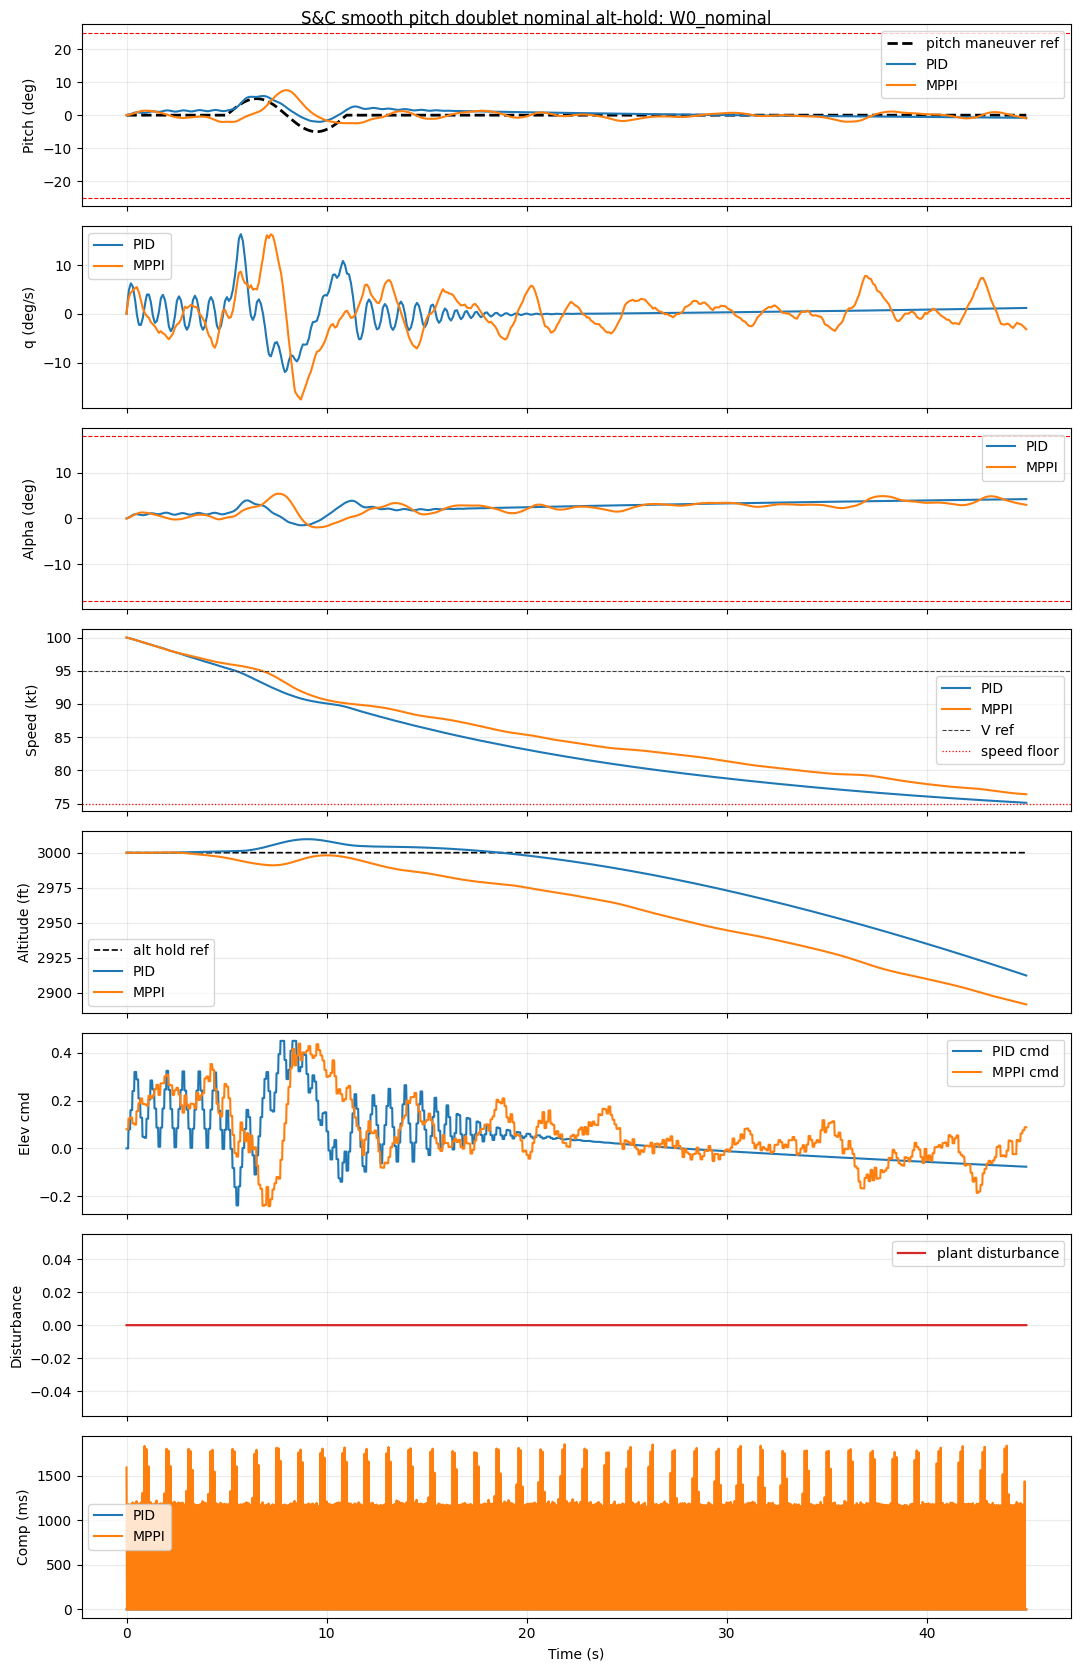

In [ ]:
def maneuver_reference_for_log(log):
    return maneuver_reference_arrays(np.asarray(log['time'], dtype=float), log['target_alt'])


def plot_case_logs(case_logs, title='Controller comparison'):
    fig, axes = plt.subplots(8, 1, figsize=(11, 17), sharex=True)
    ref_plotted = False
    for log in case_logs:
        t = np.asarray(log['time'])
        label = log['name']
        h_ref, theta_ref_deg = maneuver_reference_for_log(log)
        if not ref_plotted:
            axes[0].plot(t, theta_ref_deg, color='k', ls='--', lw=2.0, label='pitch maneuver ref')
            axes[4].plot(t, h_ref, color='k', ls='--', lw=1.2, label='alt hold ref')
            axes[6].plot(t, log['elevator_disturbance'], color='tab:red', lw=1.6, label='plant disturbance')
            ref_plotted = True
        axes[0].plot(t, log['pitch_deg'], label=label)
        axes[1].plot(t, log['pitch_rate_deg_s'], label=label)
        axes[2].plot(t, log['alpha_deg'], label=label)
        axes[3].plot(t, np.asarray(log['velocity']) / FPS_PER_KT, label=label)
        axes[4].plot(t, log['altitude'], label=label)
        axes[5].plot(t, log['elevator_cmd'], label=f'{label} cmd')
        axes[7].plot(t, log['comp_ms'], label=label)

    axes[0].axhline(PITCH_LIMIT_DEG, color='r', ls='--', lw=0.8)
    axes[0].axhline(-PITCH_LIMIT_DEG, color='r', ls='--', lw=0.8)
    axes[0].set_ylabel('Pitch (deg)')
    axes[1].set_ylabel('q (deg/s)')
    axes[2].axhline(ALPHA_LIMIT_DEG, color='r', ls='--', lw=0.8)
    axes[2].axhline(-ALPHA_LIMIT_DEG, color='r', ls='--', lw=0.8)
    axes[2].set_ylabel('Alpha (deg)')
    axes[3].axhline(GUIDANCE_AIRSPEED_KTS, color='0.25', ls='--', lw=0.8, label='V ref')
    axes[3].axhline(SPEED_FLOOR_KTS, color='r', ls=':', lw=0.9, label='speed floor')
    axes[3].set_ylabel('Speed (kt)')
    axes[4].set_ylabel('Altitude (ft)')
    axes[5].set_ylabel('Elev cmd')
    axes[6].set_ylabel('Disturbance')
    axes[7].set_ylabel('Comp (ms)')
    axes[7].set_xlabel('Time (s)')
    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend(loc='best')
    fig.suptitle(title)
    plt.tight_layout()
    return fig


plot_paths = []
for case in DISTURBANCE_CASES:
    case_name = case['name']
    case_logs = [log for log in all_logs if log.get('disturbance_case') == case_name]
    fig = plot_case_logs(case_logs, title=f'Fast S&C smooth pitch doublet simplePID vs MPPI: {case_name}')
    fig_path = os.path.join(SAVE_DIR, f'snc_smooth_pitch_doublet_two_case_fast_tracking_plot_v22_{RUN_MODE}_{case_name}.png')
    fig.savefig(fig_path, dpi=160)
    plot_paths.append(fig_path)
    print('Saved:', fig_path)
    plt.show()


## 10. Optional Full Comparison


In [ ]:
def make_test_cases(n_cases=N_TEST_CASES):
    cases = []
    rng = np.random.default_rng(SEED + 100)
    for i in range(n_cases):
        cases.append({
            'case': i,
            'init_alt': float(rng.uniform(2400, 4200)),
            'init_speed': float(rng.uniform(88, 112)),
            'init_pitch': float(rng.uniform(-4, 6)),
            'target_alt': float(rng.uniform(4400, 5600)),
        })
    return cases


all_logs = []
all_metrics = []

if RUN_MODE == 'full':
    cases = make_test_cases()
    for case in cases:
        print('Case:', case)
        for name in SELECTED_CONTROLLERS:
            ctrl = make_controller(name)
            log = run_sim(
                ctrl, name,
                init_alt=case['init_alt'],
                init_speed=case['init_speed'],
                init_pitch=case['init_pitch'],
                target_alt=case['target_alt'],
                max_steps=MAX_STEPS,
                control_interval=CONTROL_INTERVAL,
            )
            m = compute_metrics(log)
            m['Case'] = case['case']
            all_logs.append(log)
            all_metrics.append(m)

multi_metrics = pd.DataFrame(all_metrics)
if len(multi_metrics):
    multi_metrics.to_csv(os.path.join(SAVE_DIR, 'multi_case_metrics_v6_full.csv'), index=False)
multi_metrics


""


## 11. Save Logs


In [ ]:
def logs_to_frame(logs):
    rows = []
    for idx, log in enumerate(logs):
        n = len(log['time'])
        h_ref, theta_ref_deg = maneuver_reference_for_log(log)
        for k in range(n):
            rows.append({
                'log_id': idx,
                'disturbance_case': log.get('disturbance_case', 'unknown'),
                'disturbance_kind': log.get('disturbance_kind', 'unknown'),
                'controller': log['name'],
                'time': log['time'][k],
                'altitude': log['altitude'][k],
                'guidance_altitude': float(h_ref[k]),
                'guidance_error_ft': float(log['altitude'][k] - h_ref[k]),
                'theta_ref_deg': float(theta_ref_deg[k]),
                'theta_error_deg': float(log['pitch_deg'][k] - theta_ref_deg[k]),
                'velocity': log['velocity'][k],
                'velocity_kt': float(log['velocity'][k] / FPS_PER_KT),
                'speed_ref_kt': float(GUIDANCE_AIRSPEED_KTS),
                'speed_floor_kt': float(SPEED_FLOOR_KTS),
                'pitch_deg': log['pitch_deg'][k],
                'pitch_rate_deg_s': log['pitch_rate_deg_s'][k],
                'alpha_deg': log['alpha_deg'][k],
                'elevator': log['elevator'][k],
                'elevator_cmd': log['elevator_cmd'][k],
                'elevator_disturbance': log['elevator_disturbance'][k],
                'theta_cmd_deg': log['theta_cmd_deg'][k],
                'cost': log['cost'][k],
                'comp_ms': log['comp_ms'][k],
                'mpc_update': log['mpc_update'][k],
                'target_alt': log['target_alt'],
                'init_alt': log['init_alt'],
                'control_interval': log['control_interval'],
                'abort_reason': log['abort_reason'] or 'None',
            })
    return pd.DataFrame(rows)


single_log_df = logs_to_frame(logs)
multi_log_df = logs_to_frame(all_logs)
single_log_df.to_csv(os.path.join(SAVE_DIR, f'snc_smooth_pitch_doublet_two_case_fast_tracking_logs_v22_{RUN_MODE}_baseline.csv'), index=False)
multi_log_df.to_csv(os.path.join(SAVE_DIR, f'snc_smooth_pitch_doublet_two_case_fast_tracking_logs_v22_{RUN_MODE}_all_cases.csv'), index=False)
sanity_df.to_csv(os.path.join(SAVE_DIR, f'cost_sanity_snc_smooth_pitch_doublet_two_case_fast_v22_{RUN_MODE}.csv'), index=False)
speed_unit_df.to_csv(os.path.join(SAVE_DIR, f'speed_unit_sanity_v22_{RUN_MODE}.csv'), index=False)

config_path = os.path.join(SAVE_DIR, f'pinn_mpc_v6_alpha_snc_smooth_pitch_doublet_two_case_fast_config_v22_{RUN_MODE}.json')
with open(config_path, 'w') as f:
    json.dump({
        'config': CONFIG,
        'pid_params': PID_PARAMS,
        'pid_optuna_best_value': None if pid_study is None else float(pid_study.best_value),
        'model_path': MODEL_PATH,
        'pinn_params': params,
        'pinn_auto_summary': checkpoint.get('auto_summary', {}),
    }, f, indent=2)

run_manifest = {
    'experiment_family': EXPERIMENT_FAMILY,
    'experiment_name': EXPERIMENT_NAME,
    'run_stamp': RUN_STAMP,
    'save_dir': SAVE_DIR,
    'latest_dir': RESULT_LATEST_DIR,
    'run_mode': RUN_MODE,
    'model_path': MODEL_PATH,
    'generated_files': sorted([name for name in os.listdir(SAVE_DIR)]),
    'plot_paths': plot_paths,
}
with open(os.path.join(SAVE_DIR, 'RUN_MANIFEST.json'), 'w') as f:
    json.dump(run_manifest, f, indent=2)
with open(os.path.join(RESULT_MODEL_DIR, 'LATEST_RUN.json'), 'w') as f:
    json.dump(run_manifest, f, indent=2)

print('Saved archived results to:', SAVE_DIR)
print('Updated latest run pointer:', os.path.join(RESULT_MODEL_DIR, 'LATEST_RUN.json'))


Saved archived results to: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_nominal_alt_hold_horizon_PID_MPPI_Optuna_v20/archive/20260503_020357
Updated latest run pointer: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_snc_smooth_pitch_doublet_nominal_alt_hold_horizon_PID_MPPI_Optuna_v20/LATEST_RUN.json


## 12. Linear Guidance Single 125s Tracking Guide v22

Use this notebook to test 60-second tracking against a simple explicit reference.

Default run:

1. `RUN_MODE = "single"`
2. Controllers: `PID`, `MPPI` only
3. Initial altitude: `INIT_ALT = 3000 ft`
4. Target altitude: `TARGET_ALT = 4000 ft`
5. Linear reference: 3000 -> 4000 ft over `GUIDANCE_CLIMB_TIME_S = 120 s`
6. Quick settings: `MPC_HORIZON = 150`, `MPC_SAMPLES = 24`, `CONTROL_INTERVAL = 10`, `MAX_STEPS = 3000`

What to inspect:

- `sanity_df`: whether the cost prefers a sequence that follows the linear climb reference
- `quick_check`: whether PID and MPPI both climb in JSBSim
- `tracking_summary`: Alt RMSE, Final Error, Alt Change, Pitch/Alpha limits, Elevator Smoothness, and computation time

Why this version exists:

- The previous shaped guidance could be too flat over a short horizon.
- This version gives the controller an explicit slope: `(5000 - 3000) / 60 = 33.3 ft/s`.
- The objective is controller testing, not guidance-generation research.

Extension path:

- Add `make_maneuver_guidance(..., maneuver="pitch_doublet")` for elevator/pitch doublet tests.
- Add pull-up, pushover, and pull-up/pull-over references with the same return contract.
- Once PID/MPPI track these references, move to `make_task_guidance()` and then wind/disturbance tests.


Checkpoint loading:

- v8 searches `/content/drive/MyDrive` for compatible `pinn_dynamics_c172_2d*.pt` files.
- It prefers `pinn_dynamics_c172_2d_v6_alpha.pt`, then compatible v7 guidance checkpoints.
- If no checkpoint is found, run the training notebook or copy the checkpoint to `/content/drive/MyDrive/PINN_MODEL_ONLY_v1/`.


v9 fixes:

- PID elevator sign inverted because negative elevator is pitch-up in the current JSBSim C172 setup.
- Climb time relaxed to 120 s to reduce pitch violations.
- Progress cost softened so short-horizon MPPI is not dominated by unreachable altitude progress.
- Cost sanity now checks pitch-up direction as well as altitude change.


v10 tracking metrics:

- `Ref RMSE (ft)` compares altitude against the pitch maneuver guidance trajectory.
- `Final Ref Error (ft)` compares final altitude against the expected altitude at 125 s, about 4000 ft.
- Target-altitude error is still reported, but the 4000 ft target is not expected to be reached in 125 s because the reference is 120 s long.


v22 fast two-case simple-PID vs MPPI comparison:

- The altitude plot now includes the pitch maneuver guidance reference, the final 4000 ft target, and the expected 125 s altitude.
- Use `Ref RMSE (ft)` and `Final Ref Error (ft)` for tracking performance.
- Use `Final Error (ft)` only as distance to the final 4000 ft target, which is not expected to be reached in this 125 s run.
